<a href="https://colab.research.google.com/github/mykoladomanskyi25-dotcom/ALA_Lab1/blob/main/lab1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

(2, 74)


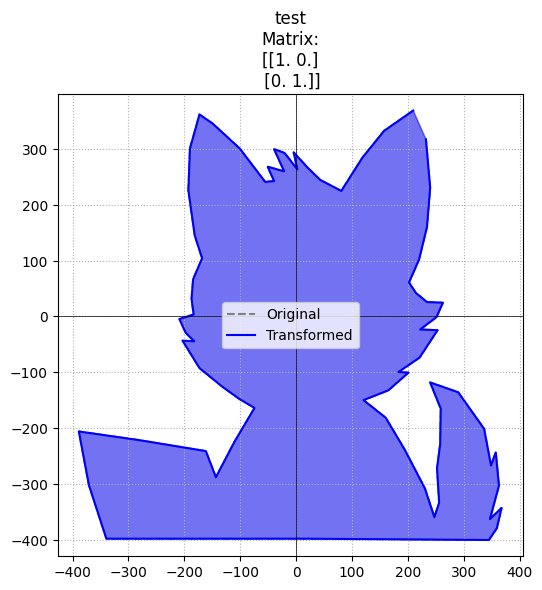

In [7]:
lynx = np.array([[209.70, 368.42], [157.63, 332.16], [118.82, 284.21], [80.95, 224.56],
    [43.08, 244.44], [20.36, 266.67], [-4.26, 293.57], [2.37, 263.16],
    [-20.36, 292.40], [-39.29, 299.42], [-21.30, 259.65], [-50.65, 267.84],
    [-39.29, 242.11], [-55.38, 240.94], [-100.83, 300.58], [-149.11, 345.03],
    [-172.78, 361.40], [-189.82, 300.58], [-192.66, 225.73], [-181.30, 145.03],
    [-168.05, 104.09], [-184.14, 66.67], [-186.98, 31.58], [-183.20, 3.51],
    [-208.76, -4.68], [-197.40, -29.24], [-182.25, -44.44], [-203.08, -43.27],
    [-172.78, -92.40], [-131.12, -126.32], [-101.78, -147.37], [-74.32, -163.74],
    [-110.30, -224.56], [-143.43, -287.72], [-161.42, -240.94], [-282.60, -221.05],
    [-388.64, -205.85], [-370.65, -301.75], [-339.41, -397.66], [18.46, -397.66],
    [345.09, -400.00], [359.29, -378.95], [367.81, -342.69], [346.98, -362.57],
    [363.08, -302.92], [357.40, -243.27], [348.88, -266.67], [336.57, -201.17],
    [290.18, -135.67], [240.00, -118.13], [258.93, -164.91], [257.99, -228.07],
    [252.31, -271.35], [256.09, -333.33], [247.57, -359.06], [230.53, -307.60],
    [194.56, -238.60], [160.47, -181.29], [120.71, -149.71], [165.21, -132.16],
    [201.18, -100.58], [183.20, -99.42], [221.07, -73.68], [253.25, -24.56],
    [222.01, -23.39], [251.36, -1.17], [262.72, 24.56], [234.32, 25.73],
    [214.44, 42.11], [202.13, 60.82], [220.12, 101.75], [234.32, 160.23],
    [240.00, 230.41], [232.43, 316.96]])
X=lynx.T
print(X.shape)

def plot_2d(original, transformed, title, matrix):
  plt.figure(figsize=(6, 6))
  plt.plot(original[0, :], original[1, :], label='Original', color='gray', linestyle='--')
  plt.fill(original[0, :], original[1, :], alpha=0.2, color='gray')

  plt.plot(transformed[0, :], transformed[1, :], label='Transformed', color='blue')
  plt.fill(transformed[0, :], transformed[1, :], alpha=0.5, color='blue')

  plt.axhline(0, color='black', linewidth=0.5)
  plt.axvline(0, color='black', linewidth=0.5)
  plt.axis('equal')
  plt.legend()
  plt.grid(True, linestyle=':')
  plt.title(f"{title}\nMatrix:\n{np.round(matrix, 2)} det = {np.linalg.det(matrix):.2f}")
  plt.show()

plot_2d(X, X, "test", np.eye(2))

In [14]:
def stretch(X, a, b):
    M = np.array([[a, 0],
                  [0, b]])
    return M @ X.copy(), M

def shear(X, a, b):
    M = np.array([[1, a],
                  [b, 1]])
    return M @ X.copy(), M

def reflection(X, a, b):
    factor = 1 / (a**2 + b**2)
    M = factor * np.array([[a**2 - b**2, 2*a*b],
                           [2*a*b, b**2 - a**2]])
    return M @ X.copy(), M

def rotation(X, theta):
    M = np.array([[np.cos(theta), -np.sin(theta)],
                  [np.sin(theta),  np.cos(theta)]])
    return M @ X.copy(), M

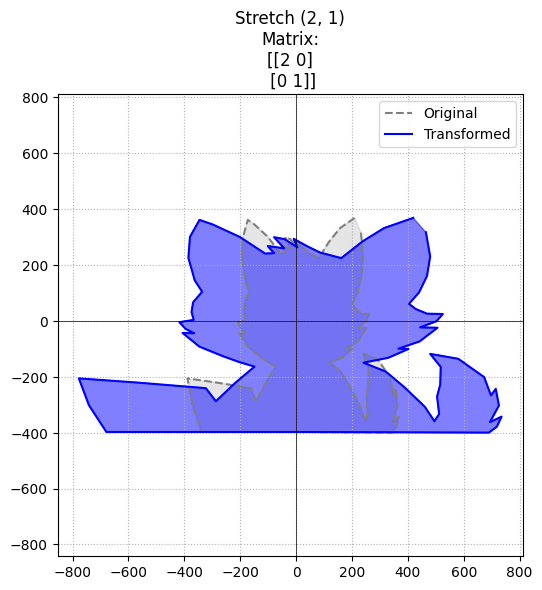

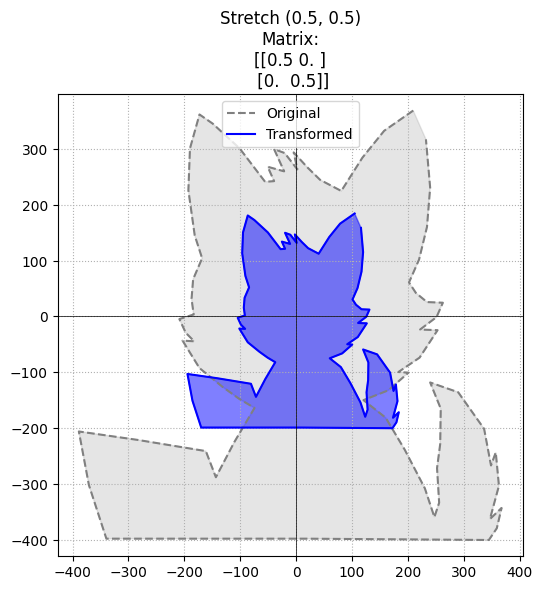

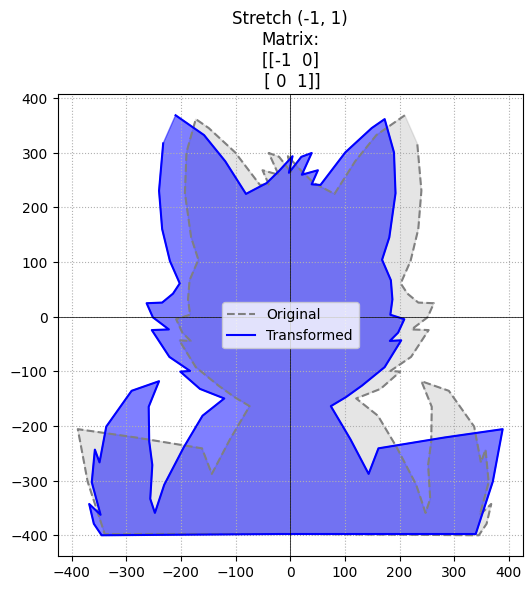

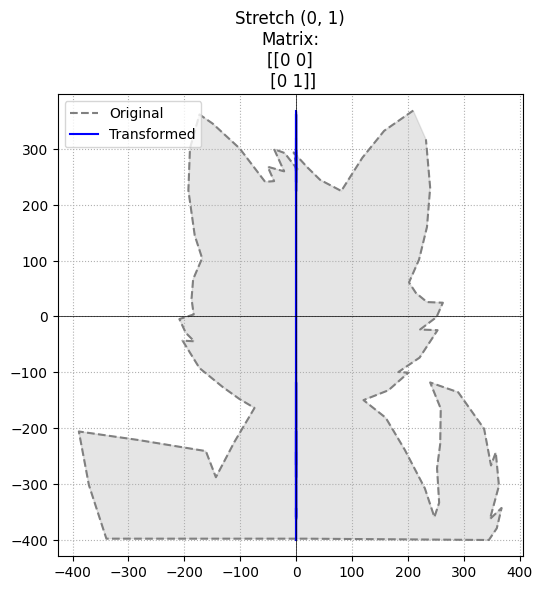

In [18]:
for a, b in [(2, 1), (0.5, 0.5), (-1, 1), (0, 1)]:
    Y, M = stretch(X, a, b)
    plot_2d(X, Y, f"Stretch ({a}, {b})", M)

In [20]:
"Коефіцієнт a розтягує фігуру по горизонталі, а b — по вертикалі. Негативні значення дзеркально відображають фігуру вздовж осі. Якщо один із коефіцієнтів дорівнює 0, визначник матриці (det) стає рівним 0, і фігура «згортається» у лінію (площа стає нульовою)."

'Коефіцієнт a розтягує фігуру по горизонталі, а b — по вертикалі. Негативні значення дзеркально відображають фігуру вздовж осі. Якщо один із коефіцієнтів дорівнює 0, визначник матриці (det) стає рівним 0, і фігура «згортається» у лінію (площа стає нульовою).'

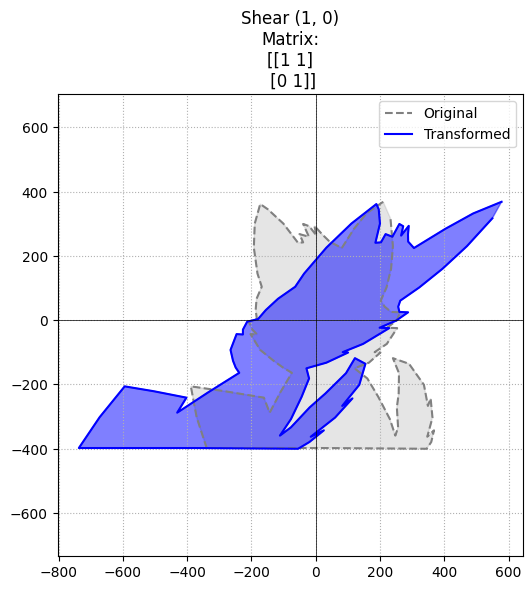

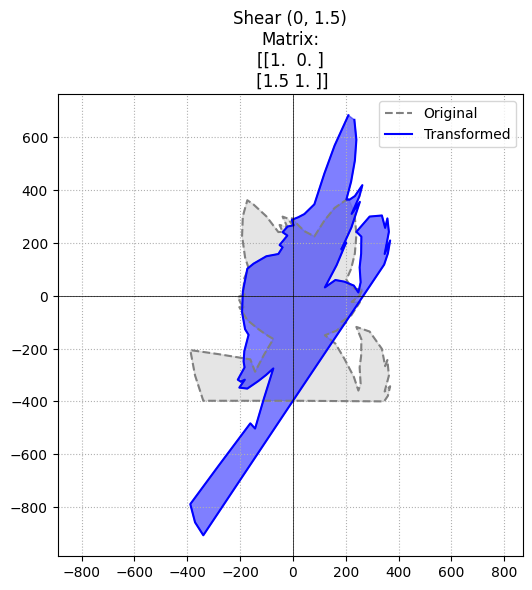

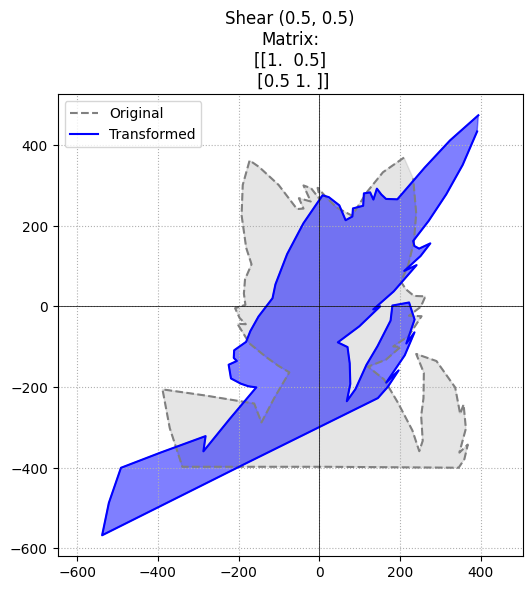

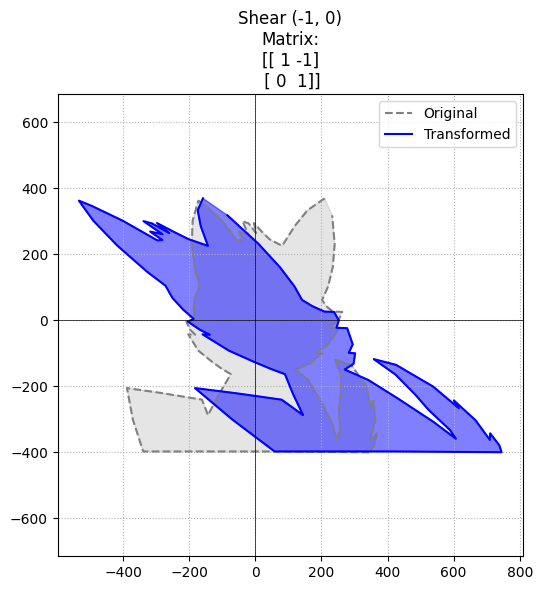

In [21]:
for a, b in [(1, 0), (0, 1.5), (0.5, 0.5), (-1, 0)]:
    Y, M = shear(X, a, b)
    plot_2d(X, Y, f"Shear ({a}, {b})", M)

In [22]:
"Определитель матриці зсуву завжди дорівнює 1. Це означає, що під час зсуву (shear) площа фігури не змінюється, вона лише нахиляється. Параметр a відповідає за нахил по осі X, а b - по осі Y."

'Определитель матриці зсуву завжди дорівнює 1. Це означає, що під час зсуву (shear) площа фігури не змінюється, вона лише нахиляється. Параметр a відповідає за нахил по осі X, а b - по осі Y.'

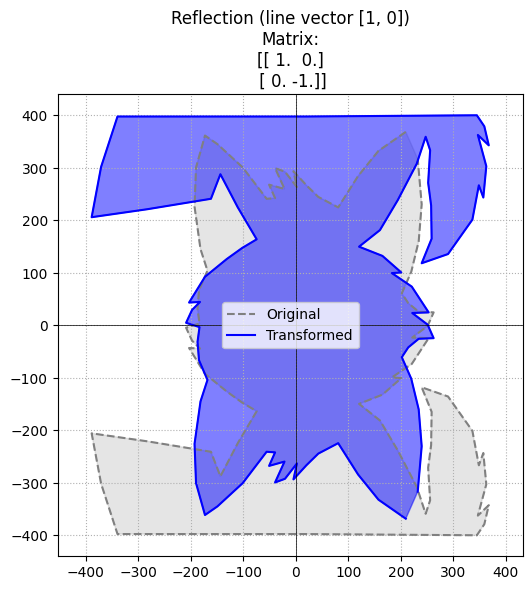

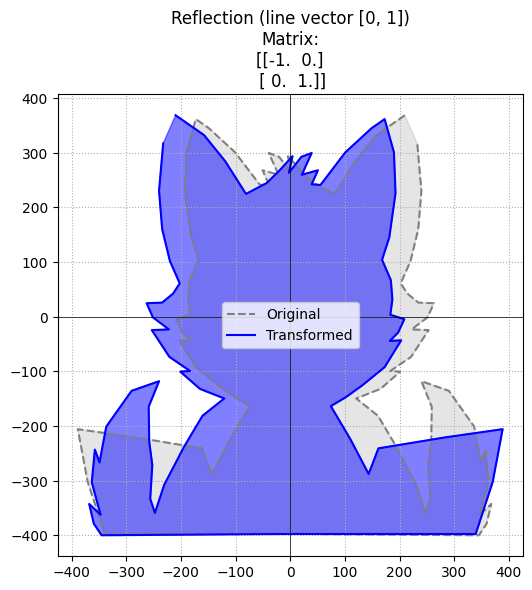

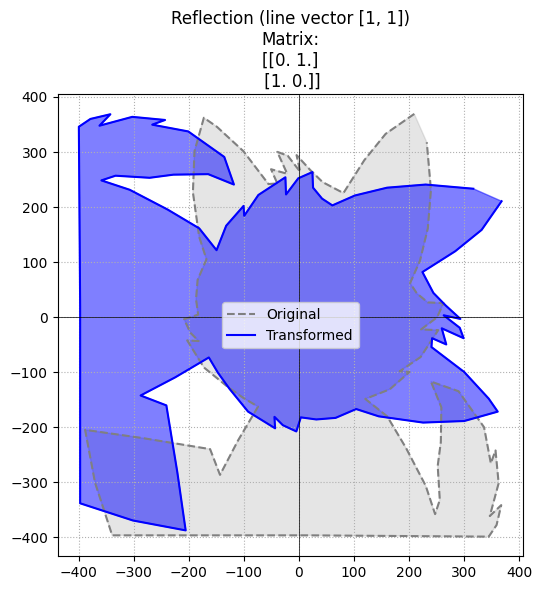

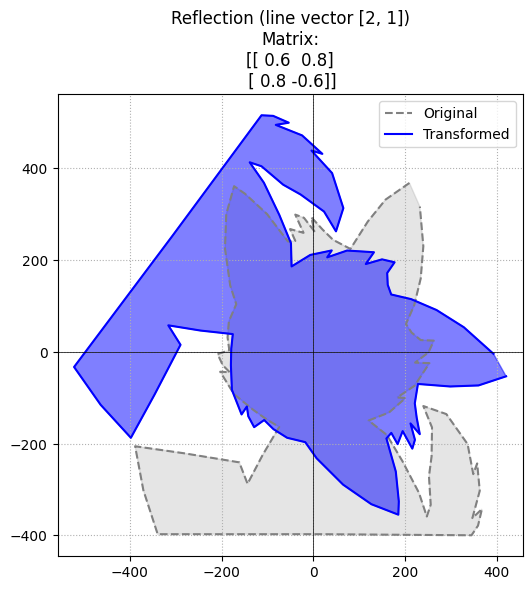

In [23]:
for a, b in [(1, 0), (0, 1), (1, 1), (2, 1)]:
    Y, M = reflection(X, a, b)
    plot_2d(X, Y, f"Reflection (line vector [{a}, {b}])", M)

In [24]:
"Фігура дзеркально відбивається відносно заданої прямої. Детермінант матриці відбиття завжди дорівнює -1. Негативний знак вказує на те, що орієнтація простору змінилася на протилежну (відбилася дзеркально), але абсолютна площа фігури залишилася незмінною."

'Фігура дзеркально відбивається відносно заданої прямої. Детермінант матриці відбиття завжди дорівнює -1. Негативний знак вказує на те, що орієнтація простору змінилася на протилежну (відбилася дзеркально), але абсолютна площа фігури залишилася незмінною.'

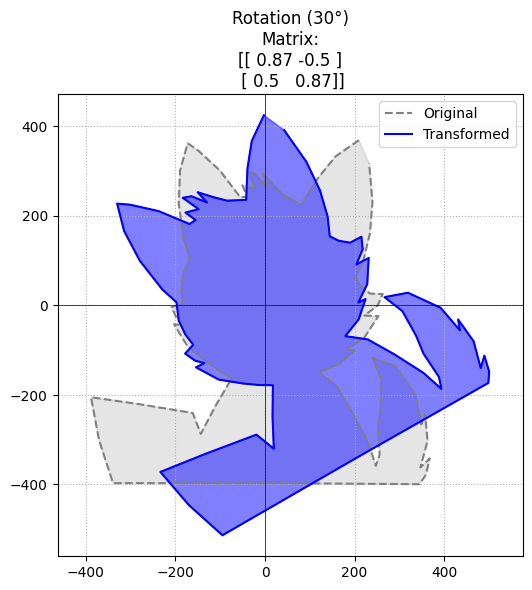

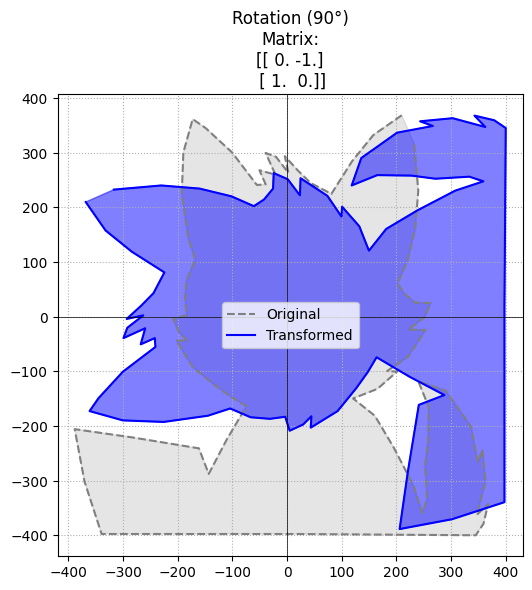

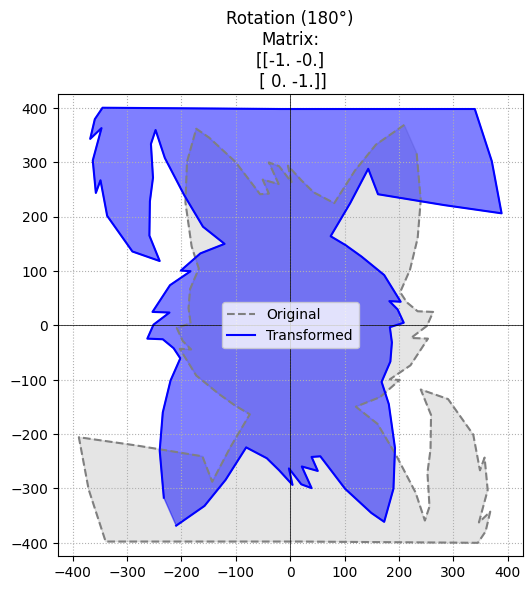

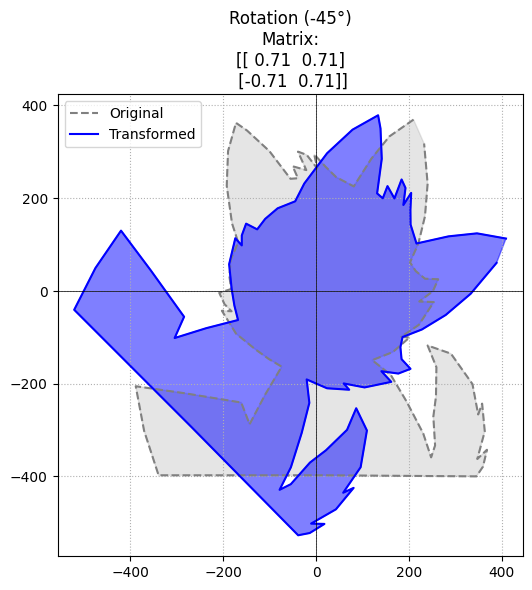

In [25]:
for deg in [30, 90, 180, -45]:
    Y, M = rotation(X, np.deg2rad(deg))
    plot_2d(X, Y, f"Rotation ({deg}°)", M)

In [26]:
"Додатні значення кута обертають фігуру проти годинникової стрілки, а від’ємні - за годинниковою стрілкою. Визначник матриці обертання завжди дорівнює саме 1, оскільки обертання є жорстким перетворенням: воно повністю зберігає як площу, так і орієнтацію вихідної фігури."

'Додатні значення кута обертають фігуру проти годинникової стрілки, а від’ємні - за годинниковою стрілкою. Визначник матриці обертання завжди дорівнює саме 1, оскільки обертання є жорстким перетворенням: воно повністю зберігає як площу, так і орієнтацію вихідної фігури.'

TASK 1: 2D Transformations


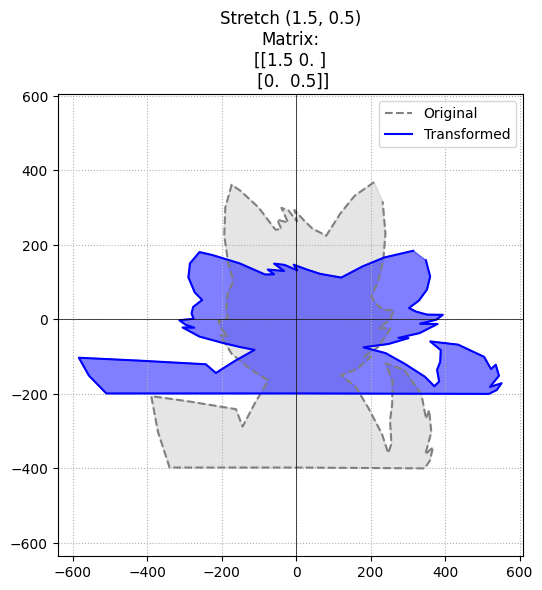

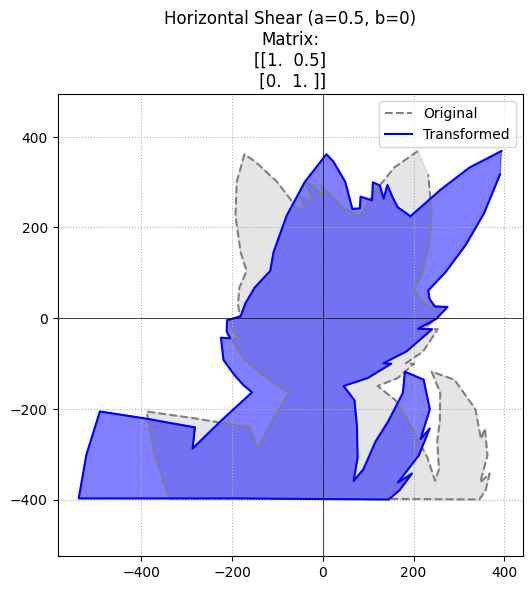

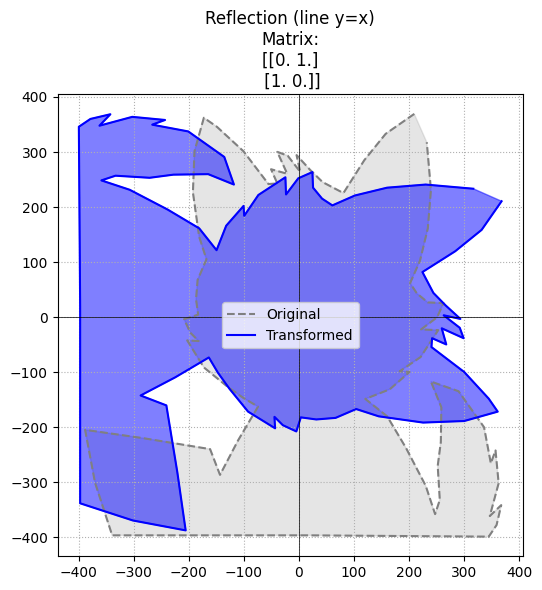

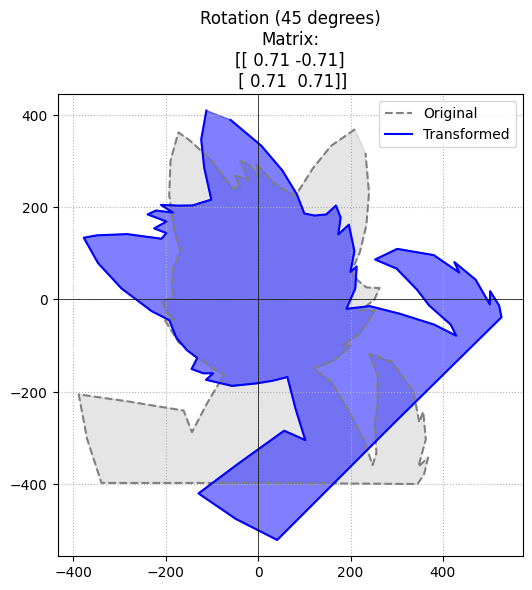

In [27]:
print("TASK 1: 2D Transformations")
X_stretch, M_st = stretch(X, 1.5, 0.5)
plot_2d(X, X_stretch, "Stretch (1.5, 0.5)", M_st)

X_shear, M_sh = shear(X, 0.5, 0)
plot_2d(X, X_shear, "Horizontal Shear (a=0.5, b=0)", M_sh)

X_refl, M_rf = reflection(X, 1, 1)
plot_2d(X, X_refl, "Reflection (line y=x)", M_rf)

X_rot, M_rt = rotation(X, np.pi/4)
plot_2d(X, X_rot, "Rotation (45 degrees)", M_rt)


--- TASK 2: Composition of 2D Transformations ---


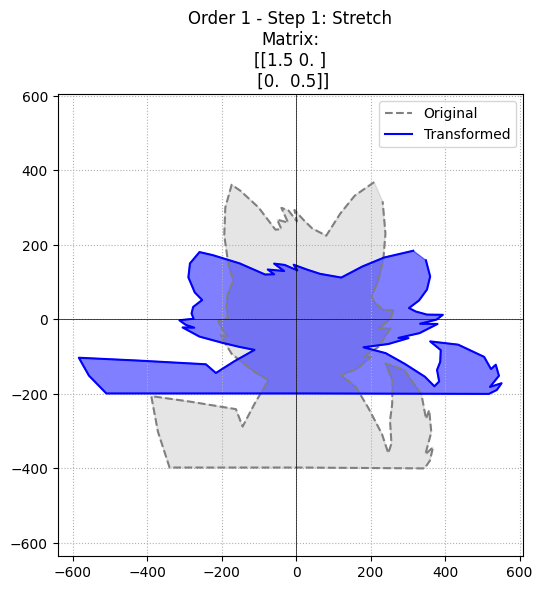

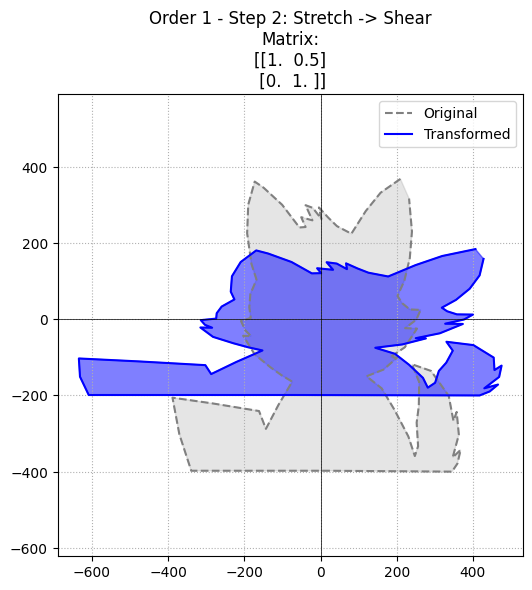

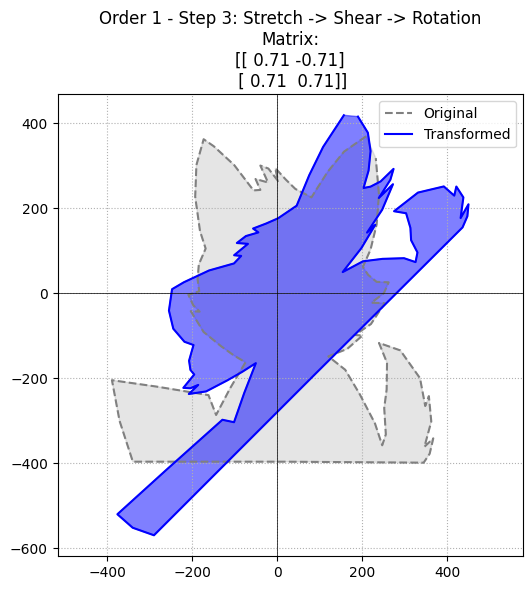

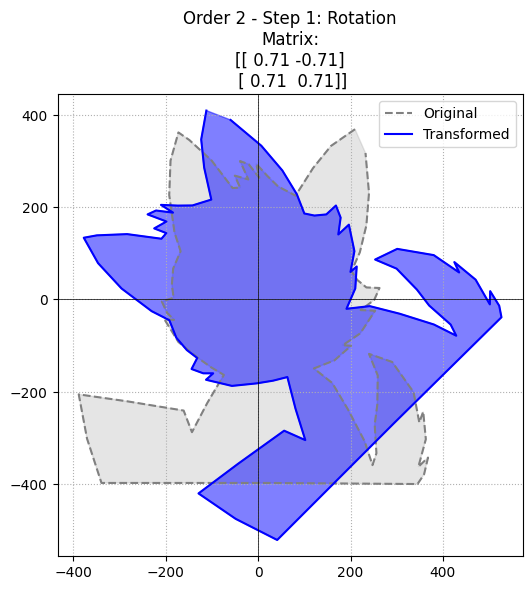

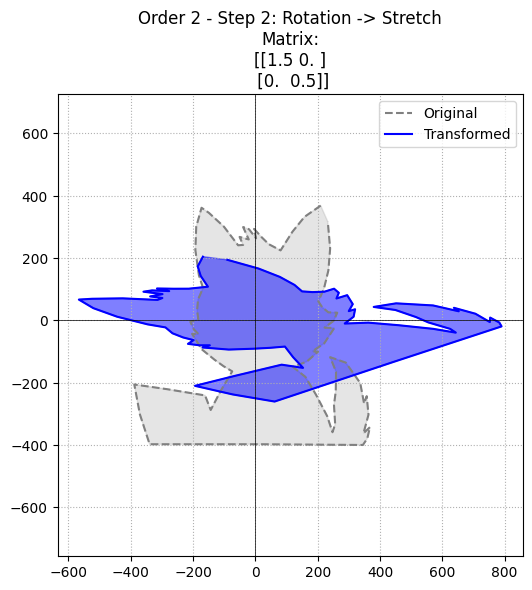

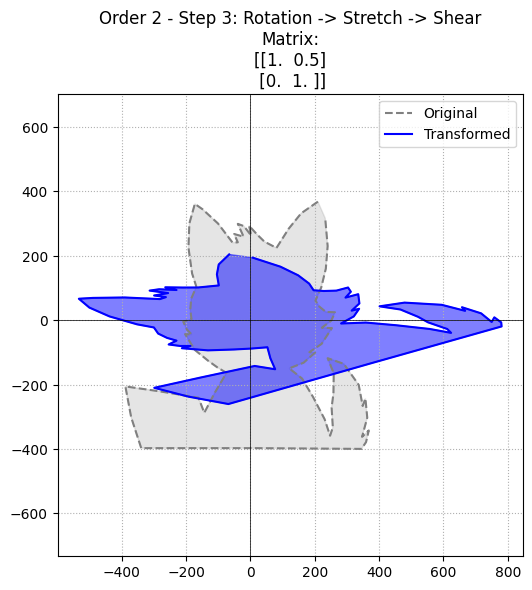

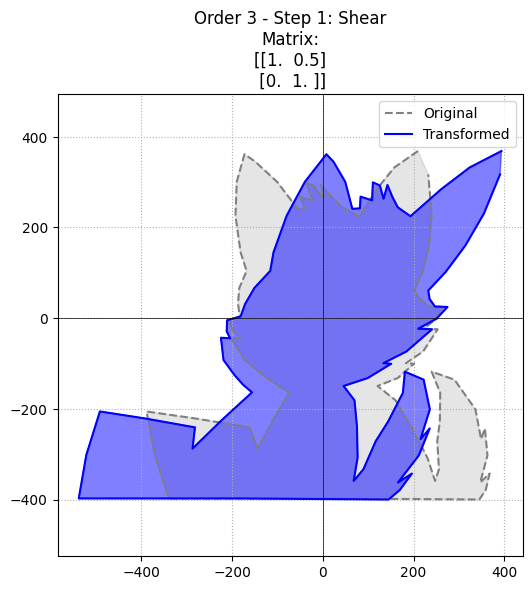

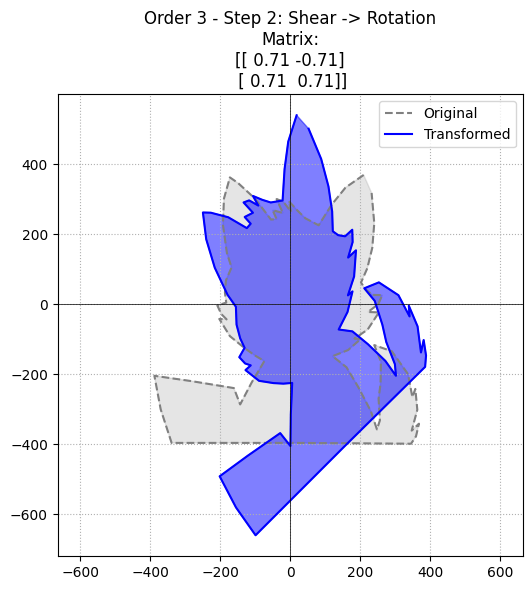

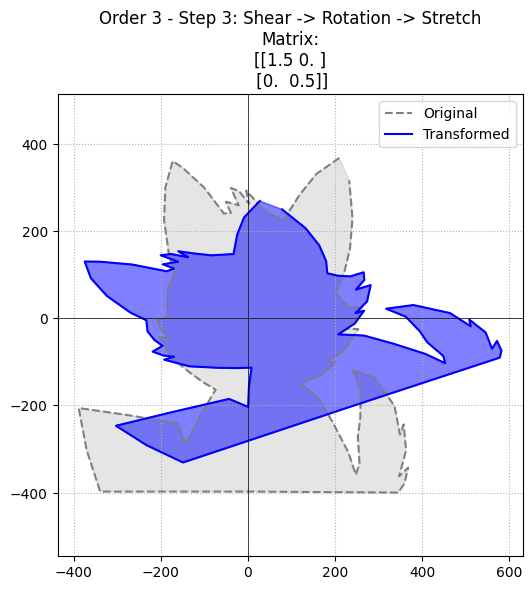

M_comp1 == M_comp2? False
M_comp1 == M_comp3? False
M_comp2 == M_comp3? False
Порядок 1 (X1_3 == M_comp1 @ X): True
Порядок 2 (X2_3 == M_comp2 @ X): True
Порядок 3 (X3_3 == M_comp3 @ X): True
det(M_comp1) = 0.75
det(M_comp2) = 0.75
det(M_comp3) = 0.75


In [37]:
print("\n--- TASK 2: Composition of 2D Transformations ---")

a_st, b_st = 1.5, 0.5
a_sh, b_sh = 0.5, 0
angle = np.pi / 4

X1_1, M1_st = stretch(X, a_st, b_st)
plot_2d(X, X1_1, "Order 1 - Step 1: Stretch", M1_st)

X1_2, M1_sh = shear(X1_1, a_sh, b_sh)
plot_2d(X, X1_2, "Order 1 - Step 2: Stretch -> Shear", M1_sh)

X1_3, M1_rt = rotation(X1_2, angle)
plot_2d(X, X1_3, "Order 1 - Step 3: Stretch -> Shear -> Rotation", M1_rt)

M_comp1 = M1_rt @ M1_sh @ M1_st

X2_1, M2_rt = rotation(X, angle)
plot_2d(X, X2_1, "Order 2 - Step 1: Rotation", M2_rt)

X2_2, M2_st = stretch(X2_1, a_st, b_st)
plot_2d(X, X2_2, "Order 2 - Step 2: Rotation -> Stretch", M2_st)

X2_3, M2_sh = shear(X2_2, a_sh, b_sh)
plot_2d(X, X2_3, "Order 2 - Step 3: Rotation -> Stretch -> Shear", M2_sh)

M_comp2 = M2_sh @ M2_st @ M2_rt

X3_1, M3_sh = shear(X, a_sh, b_sh)
plot_2d(X, X3_1, "Order 3 - Step 1: Shear", M3_sh)

X3_2, M3_rt = rotation(X3_1, angle)
plot_2d(X, X3_2, "Order 3 - Step 2: Shear -> Rotation", M3_rt)

X3_3, M3_st = stretch(X3_2, a_st, b_st)
plot_2d(X, X3_3, "Order 3 - Step 3: Shear -> Rotation -> Stretch", M3_st)

M_comp3 = M3_st @ M3_rt @ M3_sh


print("M_comp1 == M_comp2?", np.allclose(M_comp1, M_comp2))
print("M_comp1 == M_comp3?", np.allclose(M_comp1, M_comp3))
print("M_comp2 == M_comp3?", np.allclose(M_comp2, M_comp3))


print("Порядок 1 (X1_3 == M_comp1 @ X):", np.allclose(X1_3, M_comp1 @ X))
print("Порядок 2 (X2_3 == M_comp2 @ X):", np.allclose(X2_3, M_comp2 @ X))
print("Порядок 3 (X3_3 == M_comp3 @ X):", np.allclose(X3_3, M_comp3 @ X))


print("det(M_comp1) =", round(np.linalg.det(M_comp1), 4))
print("det(M_comp2) =", round(np.linalg.det(M_comp2), 4))
print("det(M_comp3) =", round(np.linalg.det(M_comp3), 4))

In [39]:
"Так, кінцевий результат залежить від порядку перетворень. Підсумкові матриці не збігаються одна з одною, і на графіках ми бачимо зовсім різні за формою та положенням фігури. Чому так відбувається: Множення матриць не має властивості комутативності (AB не дорівнює BA). Порядок застосування є критично важливим, оскільки кожна наступна матриця (яка при множенні ставиться зліва) застосовується до вже спотвореного простору. При цьому перевірка підтвердила, що послідовне покрокове множення векторів дає рівно той самий результат, що й множення на одну заздалегідь перемножену композитну матрицю (M_comp @ X). Визначники однакові (0.75): Незважаючи на те, що фігури виглядають по-різному, їхня підсумкова площа змінилася абсолютно однаково. Це математично логічно: визначник добутку матриць завжди дорівнює добутку їхніх визначників det(ABC) = det(A) * det(B) * det(C)). Цікавий факт: Різні порядки перетворень можуть дати однаковий результат лише в особливих випадках, коли матриці комутують. Наприклад, результат не залежав би від порядку, якби ми комбінували лише поворот (rotation) та рівномірне масштабування (dilation, тобто stretch з однаковими коефіцієнтами a=b)."

'Так, кінцевий результат залежить від порядку перетворень. Підсумкові матриці не збігаються одна з одною, і на графіках ми бачимо зовсім різні за формою та положенням фігури. Чому так відбувається: Множення матриць не має властивості комутативності (AB не дорівнює BA). Порядок застосування є критично важливим, оскільки кожна наступна матриця (яка при множенні ставиться зліва) застосовується до вже спотвореного простору. При цьому перевірка підтвердила, що послідовне покрокове множення векторів дає рівно той самий результат, що й множення на одну заздалегідь перемножену композитну матрицю (M_comp @ X). Визначники однакові (0.75): Незважаючи на те, що фігури виглядають по-різному, їхня підсумкова площа змінилася абсолютно однаково. Це математично логічно: визначник добутку матриць завжди дорівнює добутку їхніх визначників det(ABC) = det(A) * det(B) * det(C)). Цікавий факт: Різні порядки перетворень можуть дати однаковий результат лише в особливих випадках, коли матриці комутують. Наприкл


TASK 3: 3D Rotations


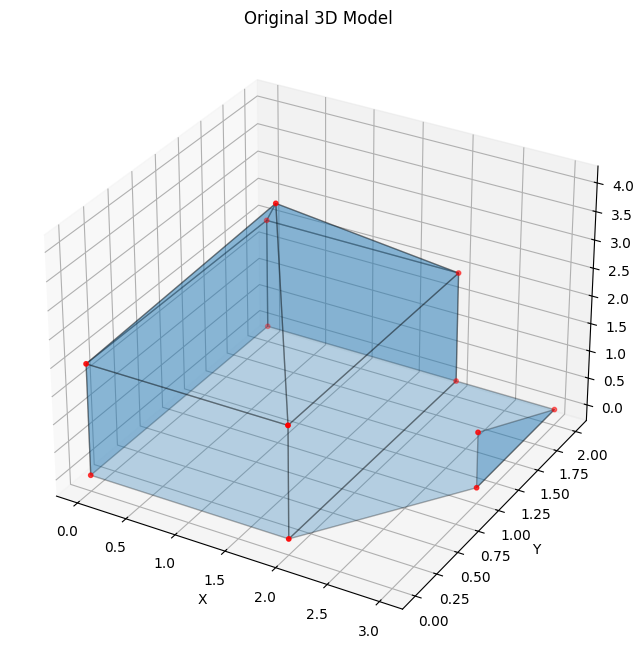

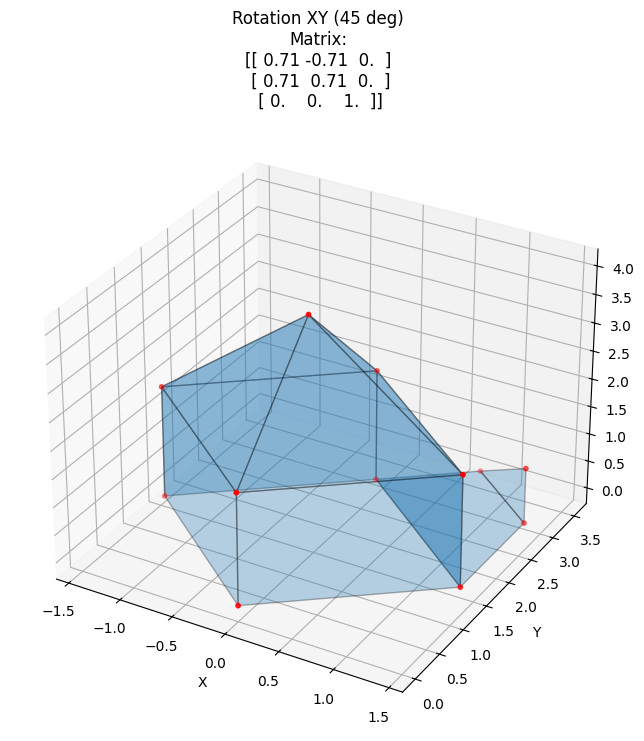

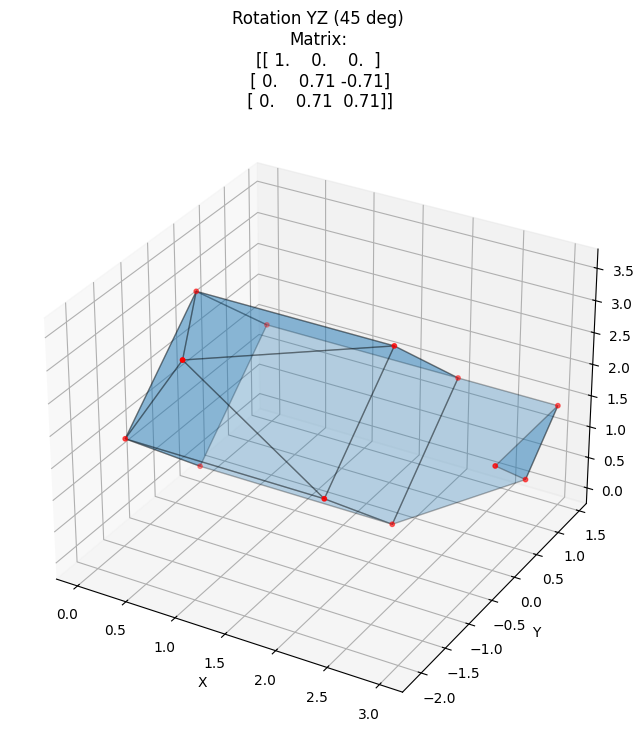

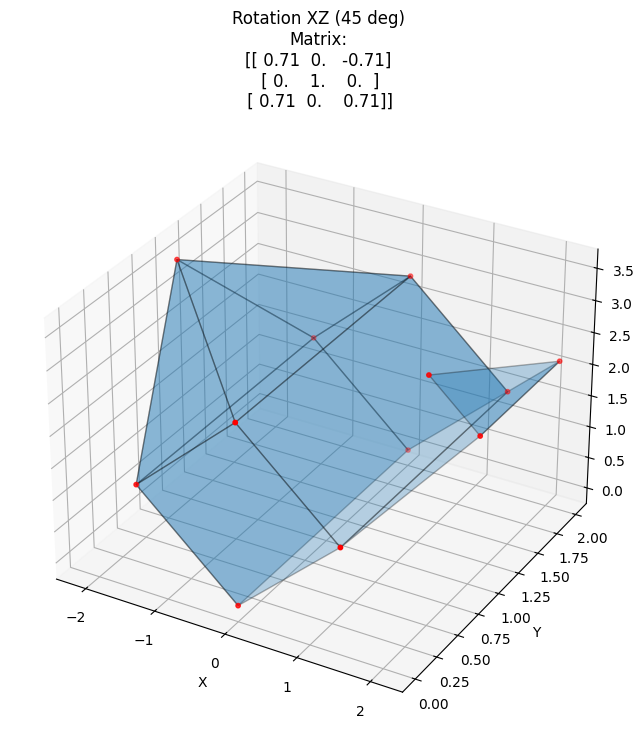